In [418]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [419]:
import numpy as np
import ipywidgets as widgets
from IPython.display import display
import torch
import torch.nn as nn
import torch.nn.functional as F
import os
import json
import math
import pickle
from collections import deque

import gc, time, math
import numpy as np
import pandas as pd
import torch
from torch import nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset, TensorDataset

import torchvision.transforms as T

from tqdm import tqdm

import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from matplotlib.patches import Rectangle

from IPython.display import clear_output

# Set high default resolution for figures
plt.rcParams['figure.dpi'] = 100

from bioplnn.models import (
    SpatiallyEmbeddedClassifier,
    SpatiallyEmbeddedAreaConfig,
    SpatiallyEmbeddedRNN,
    Ablation,
)
from bioplnn.datasets import Mazes
from bioplnn.utils import initialize_dataloader

# Data and checkpoint paths
maze_data_path = "/home/jackking/torch-bioplnn-dev/data/mazes"
checkpoint_path = "/home/jackking/torch-bioplnn-dev/train/checkpoints/"

# Torch setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.set_float32_matmul_precision("high")

In [ ]:
class SimpleCNN(nn.Module):
    def __init__(self, in_channels=4, num_classes=2, dropout=0.3):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels, 64,  kernel_size=5, padding=2)
        self.conv2 = nn.Conv2d(64,          64, kernel_size=5, padding=2)
        self.conv3 = nn.Conv2d(64,         128, kernel_size=5, padding=2)
        self.pool  = nn.MaxPool2d(2, 2)
        self.relu  = nn.ReLU(inplace=True)
        self.dropout = nn.Dropout(dropout)

        self.fc1 = nn.Linear(128 * 6 * 6, 512)
        self.fc2 = nn.Linear(512, num_classes)

    def forward(self, x):
        x = self.pool(self.relu(self.conv1(x)))
        x = self.pool(self.relu(self.conv2(x))) 
        x = self.pool(self.relu(self.conv3(x)))
        x = torch.flatten(x, 1)
        x = self.dropout(self.relu(self.fc1(x)))
        return self.fc2(x)

def prepare_rnn_weights(state_dict):
    """Remove 'rnn.' prefix from all keys in the state dict.
        Also remove any key starting with readout"""
    new_state_dict = {}
    for key, value in state_dict.items():
        if key.startswith('rnn.'):
            new_key = key[4:]  # Remove 'rnn.' prefix
            new_state_dict[new_key] = value
        elif not key.startswith('readout'):
            new_state_dict[key] = value
    return new_state_dict
    
    
def load_model_and_config(wandb_name, checkpoint, full_cfg=None):
    """Load model configuration and instantiate models."""
    if full_cfg is None:
        full_cfg = pickle.load(open(checkpoint_path + f"{wandb_name}.pkl", "rb"))

    model_cfg = full_cfg["model_config"]

    if "num_steps" in full_cfg:
        num_steps = full_cfg["num_steps"]
    else:
        num_steps = 20
        
    print(full_cfg)
        
    if full_cfg["model_type"] == "cnn":
        model = SimpleCNN(in_channels=model_cfg["in_channels"], num_classes=model_cfg["num_classes"])
        classifier = SimpleCNN(in_channels=model_cfg["in_channels"], num_classes=model_cfg["num_classes"])
    else:
        model = SpatiallyEmbeddedRNN(**model_cfg["rnn_kwargs"])
        classifier = SpatiallyEmbeddedClassifier(**model_cfg)

        # ——— Load checkpoint & weights ———
    try:
        state_dict = torch.load(checkpoint_path + f"{wandb_name}_{checkpoint}.pth", map_location=torch.device('cpu'))
    except:
        state_dict = torch.load(checkpoint_path + f"{wandb_name}/{checkpoint}.pth", map_location=torch.device('cpu'))

    try:
        state_dict = state_dict["model_state"]
    except:
        pass

    model.load_state_dict(prepare_rnn_weights(state_dict))
    classifier.load_state_dict(state_dict)

    return model, classifier, num_steps, full_cfg, state_dict

In [ ]:
class GridSelector:
    def __init__(self, n_rows, n_cols, cell_size_px=28):
        self.n_rows = n_rows
        self.n_cols = n_cols

        # Create toggle buttons
        self._toggles = [
            widgets.ToggleButton(
                value=False,
                description="",
                tooltip=f"({r},{c})",
                layout=widgets.Layout(
                    width=f"{cell_size_px}px",
                    height=f"{cell_size_px}px",
                    padding="0px",
                    margin="0px",
                ),
                button_style="",  # we'll rely on custom style below
            )
            for r in range(n_rows) for c in range(n_cols)
        ]

        # Grid container
        self._grid = widgets.GridBox(
            self._toggles,
            layout=widgets.Layout(
                grid_template_columns=" ".join([f"{cell_size_px}px"] * n_cols),
                grid_gap="2px 2px",
            ),
        )

        # Controls
        self._btn_clear = widgets.Button(description="Clear", button_style="")
        self._btn_fill = widgets.Button(description="Fill", button_style="")
        self._out = widgets.Output()

        self._btn_clear.on_click(self._on_clear)
        self._btn_fill.on_click(self._on_fill)

        # Optional: color feedback via CSS classes (works in classic Jupyter + most JupyterLab)
        display(widgets.HTML("""
        <style>
        .gridsel .widget-toggle-button button { background: #f6f6f6; }
        .gridsel .widget-toggle-button.gridsel-on button { background: #222; color: white; }
        </style>
        """))

        # Attach observers to update styling
        for t in self._toggles:
            t.observe(self._on_toggle, names="value")
            t.add_class("gridsel")

        # Initial style sync
        for t in self._toggles:
            self._sync_style(t)

    def _idx(self, r, c):
        return r * self.n_cols + c

    def _on_toggle(self, change):
        # change['owner'] is the widget
        self._sync_style(change["owner"])

    def _sync_style(self, toggle):
        if toggle.value:
            toggle.add_class("gridsel-on")
        else:
            toggle.remove_class("gridsel-on")

    def _on_clear(self, _):
        for t in self._toggles:
            t.value = False

    def _on_fill(self, _):
        for t in self._toggles:
            t.value = True

    def array(self, dtype=np.int8):
        arr = np.zeros((self.n_rows, self.n_cols), dtype=dtype)
        for r in range(self.n_rows):
            for c in range(self.n_cols):
                arr[r, c] = 1 if self._toggles[self._idx(r, c)].value else 0
        return arr

    def set_array(self, arr):
        arr = np.asarray(arr)
        assert arr.shape == (self.n_rows, self.n_cols)
        for r in range(self.n_rows):
            for c in range(self.n_cols):
                self._toggles[self._idx(r, c)].value = bool(arr[r, c])

    def show(self):
        controls = widgets.HBox([self._btn_clear, self._btn_fill])
        display(widgets.VBox([controls, self._grid]))
        return self

def get_decision_point(classifier, num_steps, inp, device):
    classifier.eval()
    classifier.to(device)
    with torch.no_grad():
        for step in range(num_steps):
            logits = classifier(inp, num_steps=step)
            if np.argmax(logits.cpu().numpy()) == 1:
                return step
    return num_steps

In [ ]:
## MAZES ##

wandb_name, checkpoint = "dauntless-elevator-522", 390 # ReLU, with I->I recurrence
cnn_wandb_name, cnn_checkpoint = "whole-sunset-502", 1540 # CNN

# ——— Load model config & instantiate ———
model, classifier, num_steps, cfg, state_dict = load_model_and_config(wandb_name, checkpoint)

model.eval()
model.to(device)

classifier.eval()
classifier.to(device)

cnn_model, cnn_classifier, cnn_num_steps, cnn_cfg, cnn_state_dict = load_model_and_config(cnn_wandb_name, cnn_checkpoint)

cnn_classifier.eval()
cnn_classifier.to(device)

In [ ]:
maze_selector = GridSelector(24, 24).show()

In [ ]:
dots_selector = GridSelector(24, 24).show()

In [ ]:
walls = maze_selector.array()
walls = walls.repeat(2, axis=0).repeat(2, axis=1)
walls = np.stack([walls, walls, walls], axis=0)   # shape (3, 48, 48)

points = dots_selector.array()
points = points.repeat(2, axis=0).repeat(2, axis=1)
points = points[np.newaxis, ...]
inp = np.concatenate([walls, points], axis=0)
plt.imshow(inp[0, 0].cpu().numpy() + inp[0, -1].cpu().numpy()*2)
plt.show()

inp = torch.tensor(inp, dtype=torch.float32).unsqueeze(0).to(device)

In [ ]:
get_decision_point(classifier, num_steps, inp, device)

In [ ]:
class ConvEncoder(nn.Module):
    def __init__(self, in_ch: int, H: int, W: int, z_dim: int = 64, hidden: int = 32):
        super().__init__()
        assert H % 8 == 0 and W % 8 == 0, "H and W must be divisible by 8 for this 3x stride-2 conv encoder."
        self.H, self.W = H, W
        self.z_dim = z_dim

        self.conv = nn.Sequential(
            nn.Conv2d(in_ch, hidden,     4, 2, 1), nn.ReLU(),   # /2
            nn.Conv2d(hidden, hidden*2,  4, 2, 1), nn.ReLU(),   # /4
            nn.Conv2d(hidden*2, hidden*4,4, 2, 1), nn.ReLU(),   # /8
        )

        C = hidden * 4
        h8, w8 = H // 8, W // 8
        self.feat_shape = (C, h8, w8)
        flat = C * h8 * w8

        self.fc_mu = nn.Linear(flat, z_dim)
        self.fc_logvar = nn.Linear(flat, z_dim)

    def forward(self, x):
        h = self.conv(x)
        h = h.flatten(1)
        mu = self.fc_mu(h)
        logvar = self.fc_logvar(h)
        return mu, logvar


class ConvDecoder(nn.Module):
    def __init__(self, out_ch: int, H: int, W: int, z_dim: int = 64, hidden: int = 32, feat_shape=None):
        super().__init__()
        assert H % 8 == 0 and W % 8 == 0, "H and W must be divisible by 8 for this 3x stride-2 deconv decoder."
        self.H, self.W = H, W
        self.z_dim = z_dim
        self.out_ch = out_ch

        if feat_shape is None:
            # must match encoder's feat_shape; default assumes hidden*4 channels at /8 resolution
            C = hidden * 4
            feat_shape = (C, H // 8, W // 8)

        self.feat_shape = feat_shape
        C, h8, w8 = feat_shape
        flat = C * h8 * w8

        self.fc = nn.Linear(z_dim, flat)

        # Note: channel progression mirrors encoder (C -> 2h -> h -> out)
        self.deconv = nn.Sequential(
            nn.ConvTranspose2d(C,        hidden*2, 4, 2, 1), nn.ReLU(),  # x2 => /4
            nn.ConvTranspose2d(hidden*2, hidden,   4, 2, 1), nn.ReLU(),  # x2 => /2
            nn.ConvTranspose2d(hidden,   out_ch,   4, 2, 1),             # x2 => /1 (logits)
        )

    def forward(self, z):
        h = self.fc(z)
        C, h8, w8 = self.feat_shape
        h = h.view(z.shape[0], C, h8, w8)
        logits = self.deconv(h)
        return logits


class VAE(nn.Module):
    def __init__(self, in_ch: int, out_ch: int, H: int, W: int, z_dim: int = 64, hidden: int = 32):
        super().__init__()
        self.enc = ConvEncoder(in_ch=in_ch, H=H, W=W, z_dim=z_dim, hidden=hidden)
        self.dec = ConvDecoder(out_ch=out_ch, H=H, W=W, z_dim=z_dim, hidden=hidden, feat_shape=self.enc.feat_shape)

    @staticmethod
    def reparam(mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    @staticmethod
    def kl_diag_gaussian(mu, logvar):
        # KL(q(z|x)||N(0,I)) per sample
        return 0.5 * torch.sum(torch.exp(logvar) + mu**2 - 1.0 - logvar, dim=1)

    def forward(self, x):
        mu, logvar = self.enc(x)
        z = self.reparam(mu, logvar)
        logits = self.dec(z)
        return logits, mu, logvar, z

    def encode(self, x):
        return self.enc(x)

    def decode_logits(self, z):
        return self.dec(z)

    def decode_probs(self, z):
        return torch.sigmoid(self.decode_logits(z))


# -------------------------
# Loss + training
# -------------------------

def vae_loss(x, logits, mu, logvar, beta=1.0):
    # Bernoulli recon term over all grid cells
    recon = F.binary_cross_entropy_with_logits(logits, x, reduction="none")
    recon = recon.flatten(1).sum(dim=1)  # per-sample
    kl = VAE.kl_diag_gaussian(mu, logvar)
    return (recon + beta * kl).mean(), recon.mean().item(), kl.mean().item()


def train_vae(vae, dataloader, epochs=10, lr=1e-3, beta=1.0, device="cuda"):
    vae.to(device).train()
    opt = torch.optim.Adam(vae.parameters(), lr=lr)

    for ep in tqdm(range(1, epochs + 1)):
        total = 0.0
        recon_last = kl_last = 0.0

        for batch in dataloader:
            x = batch[0] if isinstance(batch, (tuple, list)) else batch
            x = x.to(device).float()

            logits, mu, logvar, _ = vae(x)
            loss, recon_last, kl_last = vae_loss(x, logits, mu, logvar, beta=beta)

            opt.zero_grad(set_to_none=True)
            loss.backward()
            opt.step()
            total += loss.item()

        print(f"epoch {ep:03d} | loss {total/len(dataloader):.3f} | recon {recon_last:.1f} | kl {kl_last:.1f}")


# -------------------------
# Local smoothness probe
# -------------------------

@torch.no_grad()
def probe_local_smoothness(vae, x, eps_list=(0.0, 0.05, 0.1, 0.2), n_dir=8, device="cuda"):
    vae.eval().to(device)
    x = x.to(device).float()
    if x.ndim == 3:
        x = x.unsqueeze(0)

    mu, logvar = vae.encode(x)
    z0 = mu  # use mean for stability

    out = {}
    for eps in eps_list:
        dirs = torch.randn(n_dir, z0.shape[-1], device=device)
        dirs = dirs / (dirs.norm(dim=1, keepdim=True) + 1e-12)
        Z = z0.repeat(n_dir, 1) + eps * dirs
        out[eps] = vae.decode_probs(Z).cpu()
        
    return out



In [422]:
batch_size = 512
num_train_samples = batch_size * 50
num_test_samples = batch_size * 1

train_loader, test_loader = initialize_dataloader(
    seed=42, root=maze_data_path, batch_size=batch_size, dataset="mazes"
)

In [423]:
vae = VAE(in_ch=4, out_ch=4, H=48, W=48, z_dim=64, hidden=32).to(device)
train_vae(vae, train_loader, epochs=10, lr=1e-3, beta=1.0, device="cuda")
vae.eval()

 10%|█         | 1/10 [01:25<12:53, 85.96s/it]

epoch 001 | loss 2094.597 | recon 1957.2 | kl 8.2


 20%|██        | 2/10 [02:53<11:36, 87.04s/it]

epoch 002 | loss 1583.540 | recon 1031.4 | kl 126.4


 30%|███       | 3/10 [04:19<10:05, 86.51s/it]

...

 90%|█████████ | 9/10 [12:55<01:26, 86.36s/it]

epoch 009 | loss 661.276 | recon 182.7 | kl 197.8


100%|██████████| 10/10 [14:21<00:00, 86.13s/it]

epoch 010 | loss 358.494 | recon 143.0 | kl 201.2


VAE(
  (enc): ConvEncoder(
    (conv): Sequential(
      (0): Conv2d(4, 32, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
      (1): ReLU()
      (2): Conv2d(32, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
      (3): ReLU()
      (4): Conv2d(64, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
      (5): ReLU()
    )
    (fc_mu): Linear(in_features=4608, out_features=64, bias=True)
    (fc_logvar): Linear(in_features=4608, out_features=64, bias=True)
  )
  (dec): ConvDecoder(
    (fc): Linear(in_features=64, out_features=4608, bias=True)
    (deconv): Sequential(
      (0): ConvTranspose2d(128, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
      (1): ReLU()
      (2): ConvTranspose2d(64, 32, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
      (3): ReLU()
      (4): ConvTranspose2d(32, 4, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    )
  )
)

torch.Size([512, 4, 48, 48])


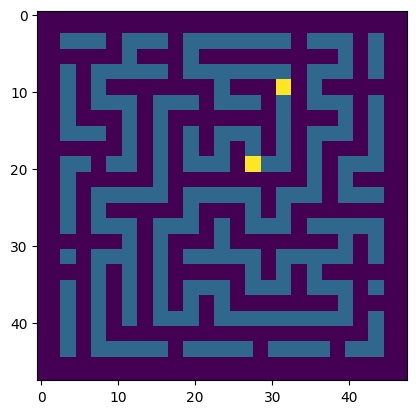

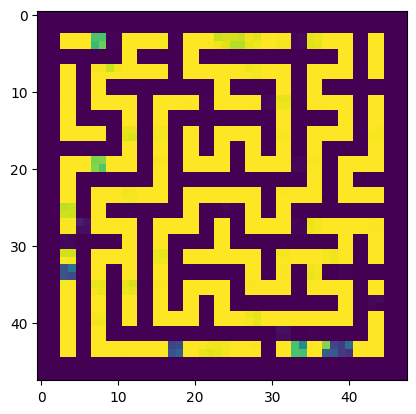

In [436]:
example_input = next(iter(test_loader))[0].to(device)
print(example_input.shape)
plt.imshow(example_input[0, 0].cpu().numpy() + example_input[0, -1].cpu().numpy()*2)
plt.show()
reconstructed_input = vae.decode_probs(vae.encode(example_input)[0]).detach().cpu()
plt.imshow(reconstructed_input[0, 1].numpy())

plt.show()

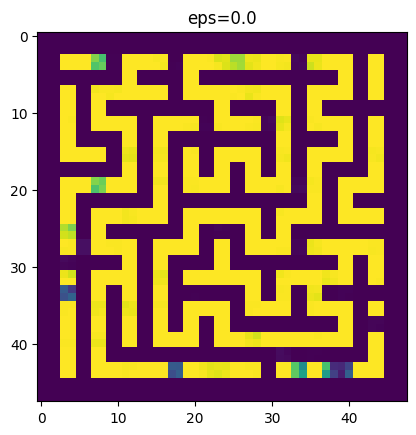

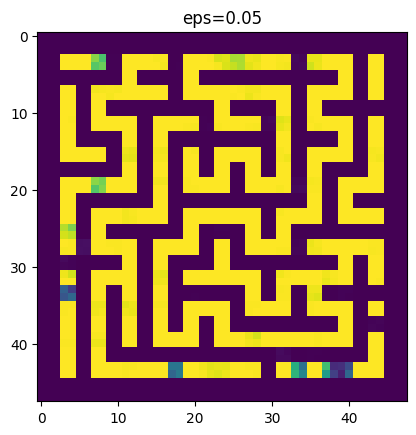

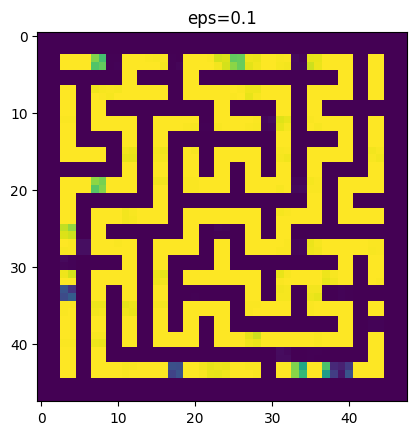

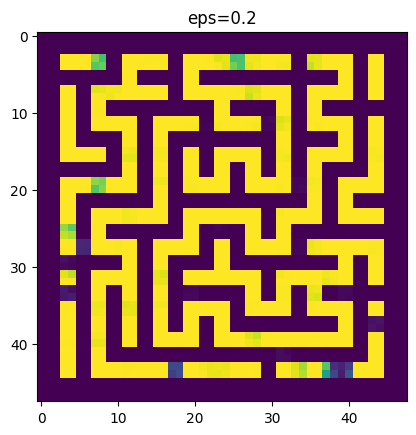

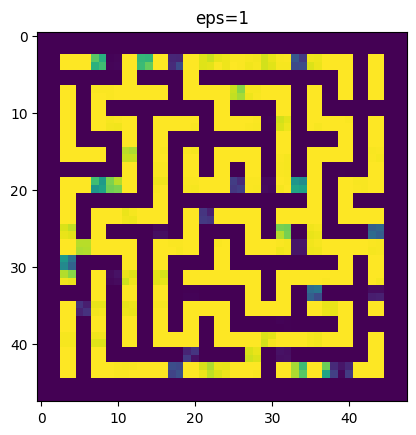

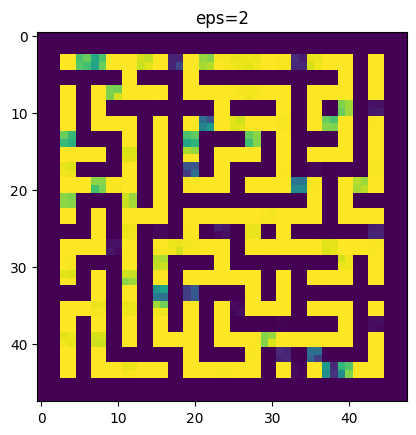

In [437]:
out = probe_local_smoothness(vae, example_input[0], eps_list=(0.0, 0.05, 0.1, 0.2, 1, 2), n_dir=8, device="cuda")
for eps, probs in out.items():
    plt.imshow(probs[0, 0].numpy())
    plt.title(f"eps={eps}")
    plt.show()
